In [6]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from IPython.display import display, HTML

In [7]:
dc=pd.read_csv(r"C:\Users\NIYA\Documents\Datascience\ds_project\course_dataset.csv")
dc

,course,total_staff,total_batches,avg_hours,department
0,Artificial Intelligence,1,1,2.0,Teaching
1,Business Analytics,1,3,6.0,Teaching
2,Cyber Security,1,2,4.0,Teaching
3,Data Science,2,4,4.0,Teaching
4,DevOps,1,2,4.0,Teaching
5,Flutter,2,3,3.0,Teaching
6,MERN,1,1,2.0,Teaching
7,PHP,1,1,2.0,Teaching
8,Python,2,6,6.0,Teaching
9,React,2,4,4.0,Teaching


In [8]:
dc.duplicated().sum()

np.int64(0)

In [9]:
dc.isnull().sum()

course           0
total_staff      0
total_batches    0
avg_hours        0
department       0
dtype: int64

In [16]:

# ── Derived columns ───────────────────────────────────────────────────────
dc['load_index']      = dc['avg_hours'] * dc['total_batches']
dc['batch_per_staff'] = (dc['total_batches'] / dc['total_staff']).round(1)

# ── KPI values ────────────────────────────────────────────────────────────
total_courses    = dc['course'].nunique()           # 11
total_staff      = dc['total_staff'].sum()          # 15
total_batches    = dc['total_batches'].sum()        # 29
avg_hours        = round(dc['avg_hours'].mean(), 1) # 3.7
top_course       = dc.loc[dc['total_batches'].idxmax(), 'course']  # Python
max_load         = dc['load_index'].max()           # 36.0 (Python)

# ── KPI Cards ─────────────────────────────────────────────────────────────
kpi_html = f"""
<div style="font-family:Arial,sans-serif; margin-bottom:24px;">
  <h3 style="color:#222; font-size:16px; margin-bottom:14px;">
  </h3>
  <div style="display:flex; gap:14px; flex-wrap:wrap;">

    <div style="background:#f0f7ff; border-top:4px solid #185FA5;
                border-radius:10px; padding:16px 22px; min-width:155px;">
      <div style="font-size:11px;color:#666;text-transform:uppercase;
                  letter-spacing:.05em;margin-bottom:6px;">Total Courses</div>
      <div style="font-size:30px;font-weight:700;color:#185FA5;">{total_courses}</div>
      <div style="font-size:11px;color:#999;margin-top:3px;">Active courses running</div>
    </div>

    <div style="background:#f0faf4; border-top:4px solid #3B6D11;
                border-radius:10px; padding:16px 22px; min-width:155px;">
      <div style="font-size:11px;color:#666;text-transform:uppercase;
                  letter-spacing:.05em;margin-bottom:6px;">Total Batches</div>
      <div style="font-size:30px;font-weight:700;color:#3B6D11;">{total_batches}</div>
      <div style="font-size:11px;color:#999;margin-top:3px;">Top: {top_course} (6 batches)</div>
    </div>

    <div style="background:#fff8f0; border-top:4px solid #854F0B;
                border-radius:10px; padding:16px 22px; min-width:155px;">
      <div style="font-size:11px;color:#666;text-transform:uppercase;
                  letter-spacing:.05em;margin-bottom:6px;">Total Staff</div>
      <div style="font-size:30px;font-weight:700;color:#854F0B;">{total_staff}</div>
      <div style="font-size:11px;color:#999;margin-top:3px;">Across all courses</div>
    </div>

    <div style="background:#f5f0ff; border-top:4px solid #534AB7;
                border-radius:10px; padding:16px 22px; min-width:155px;">
      <div style="font-size:11px;color:#666;text-transform:uppercase;
                  letter-spacing:.05em;margin-bottom:6px;">Avg Teaching Hours</div>
      <div style="font-size:30px;font-weight:700;color:#534AB7;">{avg_hours}h</div>
      <div style="font-size:11px;color:#999;margin-top:3px;">Per week per course</div>
    </div>

  </div>
</div>
"""
display(HTML(kpi_html))


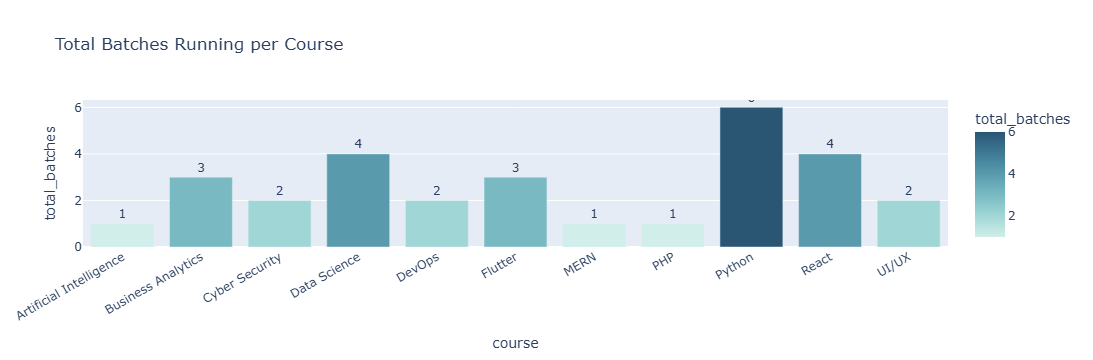

In [11]:
fig = px.bar(dc, x='course', y='total_batches',
             title='Total Batches Running per Course',
             color='total_batches',
             color_continuous_scale='Teal',
             text='total_batches')
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-30)
fig.show()

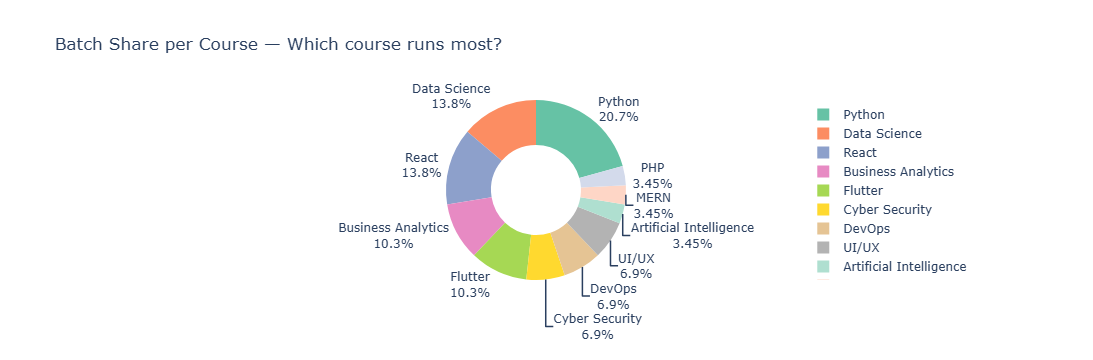

In [21]:
# ── Donut 1 — Batch share per course ─────────────────────────────────────
fig1 = px.pie(dc, names='course', values='total_batches',
              hole=0.5,
              title='Batch Share per Course — Which course runs most?',
              color_discrete_sequence=px.colors.qualitative.Set2)
fig1.update_traces(textinfo='label+percent', textposition='outside')
fig1.update_layout(showlegend=True)
fig1.show()

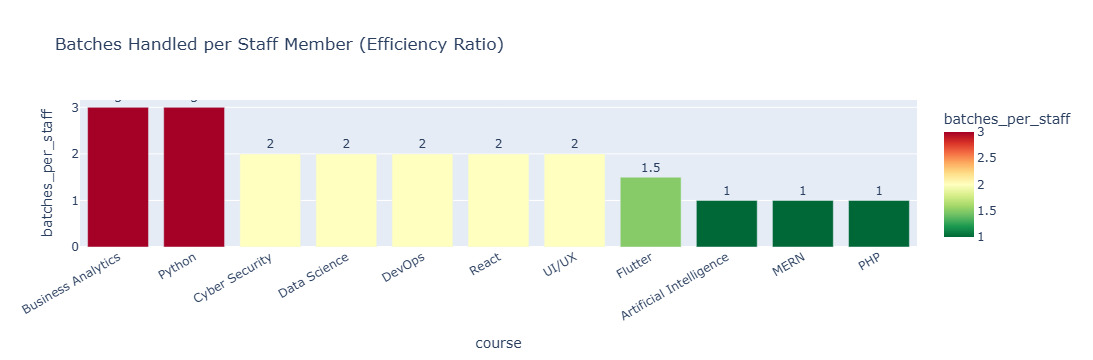

In [12]:
dc['batches_per_staff'] = (dc['total_batches'] / dc['total_staff']).round(1)

fig = px.bar(dc.sort_values('batches_per_staff', ascending=False),
             x='course', y='batches_per_staff',
             title='Batches Handled per Staff Member (Efficiency Ratio)',
             color='batches_per_staff',
             color_continuous_scale='RdYlGn_r',
             text='batches_per_staff')
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-30)
fig.show()

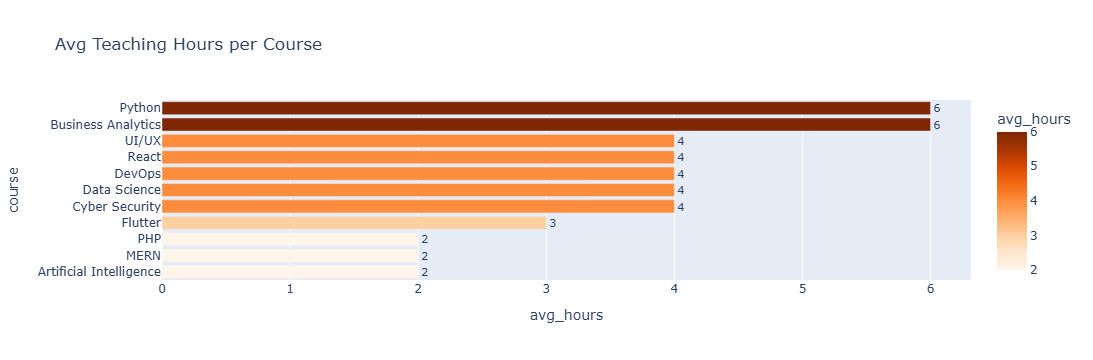

In [17]:
fig6 = px.bar(dc.sort_values('avg_hours'), x='avg_hours', y='course',
              orientation='h',
              title='Avg Teaching Hours per Course',
              color='avg_hours', color_continuous_scale='Oranges',
              text='avg_hours')
fig6.update_traces(textposition='outside')
fig6.show()

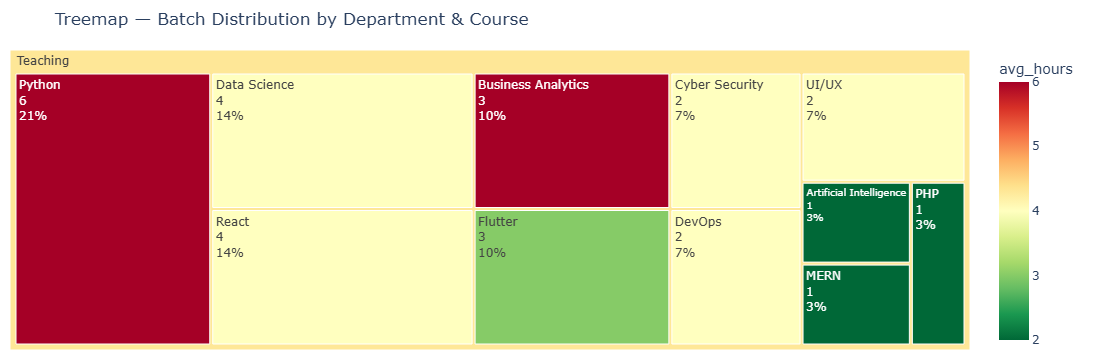

In [19]:
fig = px.treemap(
    dc,
    path=['department', 'course'],
    values='total_batches',
    title='Treemap — Batch Distribution by Department & Course',
    color='avg_hours',
    color_continuous_scale='RdYlGn_r',
    hover_data=['total_staff', 'avg_hours']
)

fig.update_traces(textinfo='label+value+percent root')
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()